#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.


### Chapter 24
**CH24A Estimating the effect of the 2010 Haiti earthquake on GDP**

using the `haiti-earthquake` dataset

version 1.0 2021-05-05

In [6]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
from plotnine import *

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")
# turning off scientific notation
pd.set_option("display.float_format", lambda x: "%.3f" % x)


In [2]:
data = pd.read_stata("/workspaces/codespaces-jupyter/data/haiti-earthquake-mod.dta")
# data = pd.read_stata("https://osf.io/download/h5yjm/")

In [3]:
dp_countries = [
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Bangladesh",
    "Cambodia",
    "Cameroon",
    "Kenya",
    "Kyrgyz Republic",
    "Liberia",
    "Madagascar",
    "Mali",
    "Moldova",
    "Mozambique",
    "Nicaragua",
    "Nepal",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Sudan",
    "Tanzania",
    "Togo",
    "Uganda",
    "Haiti",
]


In [4]:
data = data.loc[lambda x: x["country"].isin(dp_countries)]


In [5]:
haiti = data.loc[lambda x: x["country"] == "Haiti", ["year", "gdptb_us"]].reset_index(
    drop=True
)


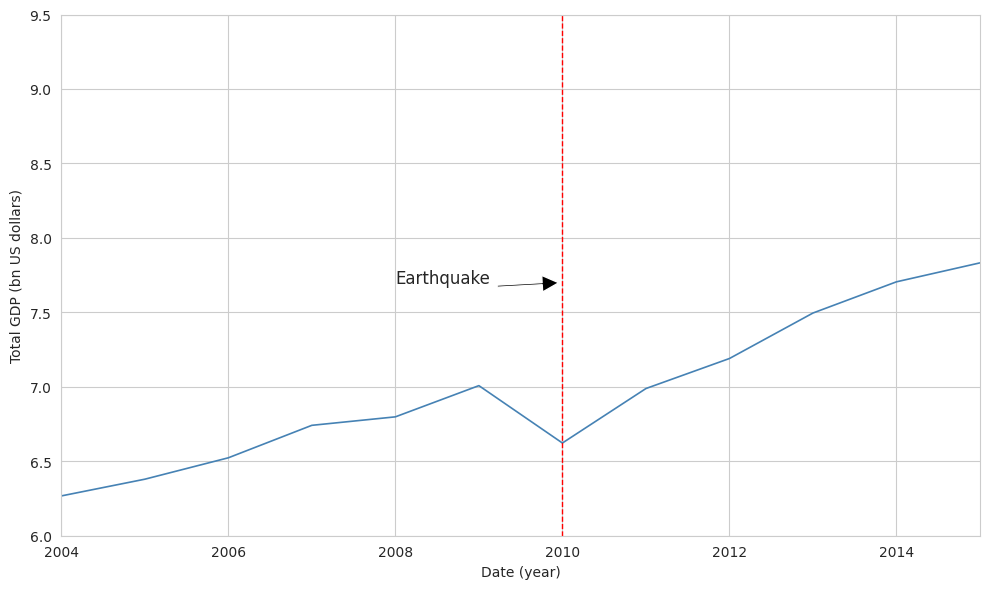

In [7]:
sns.set_style('whitegrid')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot GDP over time
ax.plot(haiti['year'], haiti['gdptb_us'], linewidth=1.2, color='steelblue')

# Add vertical line for earthquake
ax.axvline(x=2010, color='red', linestyle='dashed', linewidth=1)

# Add arrow and label
ax.annotate('Earthquake', xy=(2010, 7.7), xytext=(2008, 7.7),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=12)

# Set axis labels and limits
ax.set_xlabel('Date (year)')
ax.set_ylabel('Total GDP (bn US dollars)')
ax.set_ylim(6, 9.5)
ax.set_xlim(2004, 2015)
ax.set_xticks(np.arange(2004, 2016, 2))
ax.set_yticks(np.arange(6, 10, 0.5))

plt.tight_layout()


**NOTE:** To install the [SyntheticControlMethods](https://github.com/OscarEngelbrektson/SyntheticControlMethods) package, you have to have CMake installed on your computer (at least for Mac OS, we needed it). Follow the instructions on the CMake [website](https://cmake.org/)

In [9]:
%pip install SyntheticControlMethods
from SyntheticControlMethods import Synth

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 52.7 MB/s  0:00:006m0:00:01
  DEPRECATION: Building 'SyntheticControlMethods' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'SyntheticControlMethods'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for SyntheticControlMethods: filename=syntheticcontrolmethods-1.1.17-py2.py3-none-any.whl size=27980 sha256=5a4c77e65c5e7eea8f778b6dac0bfb7c7b2f67799b5e34f43473ee4a2b4ada83
  Stored in directory: /home/codespace/.cache/p

In [50]:
%pip install syntheticcontrol

ERROR: Could not find a version that satisfies the requirement syntheticcontrol (from versions: none)
ERROR: No matching distribution found for syntheticcontrol
Note: you may need to restart the kernel to use updated packages.


In [11]:
data = data.filter(
    [
        "country",
        "year",
        "gdptb_us",
        "cons",
        "exp",
        "imp",
        "gcf",
        "land",
        "pop",
        "inf",
        "gdppc_w",
    ]
)

In [22]:
data

,country,year,gdptb_us,cons,exp,imp,gcf,land,pop,inf,gdppc_w
180,Bangladesh,2004,80.593,79.573,11.147,15.712,24.992,130170.000,140843792.000,7.588,1844.816
181,Bangladesh,2005,85.860,79.781,14.393,20.004,25.830,130170.000,142929984.000,7.047,1936.705
182,Bangladesh,2006,91.589,79.261,16.353,21.758,26.144,130170.000,144839232.000,6.765,2038.687
183,Bangladesh,2007,98.054,79.773,16.995,22.947,26.178,130170.000,146592688.000,9.107,2156.484
184,Bangladesh,2008,104.000,81.101,17.659,24.962,26.202,130170.000,148252480.000,8.902,2260.575
...,...,...,...,...,...,...,...,...,...,...,...
2431,Uganda,2011,22.134,87.587,18.937,33.775,27.251,200520.000,34260344.000,18.693,1648.531
2432,Uganda,2012,23.110,85.823,20.126,32.972,27.024,200520.000,35400620.000,14.016,1665.809
2433,Uganda,2013,23.866,82.054,20.246,30.520,28.220,200520.000,36573388.000,5.464,1665.130
2434,Uganda,2014,25.016,82.630,18.370,28.456,27.456,200520.000,37782972.000,4.288,1689.437


In [45]:
sc = Synth(
    data,           # your full DataFrame
    "gdptb_us",     # outcome variable
    "country",      # unit identifier (treated vs control)
    "year",         # time identifier
    2010,           # treatment year
    "Haiti",        # treated unit
    pen=22,         # penalty (regularization)
    n_optim=200,    # number of optimization restarts
    random_seed=210
)

ValueError: 'x0' must only have one dimension.

In [33]:
sc = Synth(
    data,
    "gdptb_us",
    "country",
    "year",
    2010,
    "Haiti",
    pen=22,
    n_optim=200,
    random_seed=210,
)

ValueError: 'x0' must only have one dimension.

In [46]:
x0 = np.asarray(x0, dtype=float)
x0

array([[ 80.59285736,   5.67560244,   6.14463854,   1.61257195,
          7.18616247,  20.00517082,  29.57621193,   3.86616945,
          0.86670095,   7.25503254,   5.85045671,   4.61362267,
          6.52653074,  12.44459343,   7.40656376,   3.5768373 ,
         10.29299831,   1.8924706 ,  43.19781494,  21.6162529 ,
          2.67744732,  12.88769341],
       [ 85.86035919,   5.77274466,   6.67687893,   1.62708509,
          8.13833618,  20.46466064,  31.32318115,   3.85938239,
          0.91247988,   7.588974  ,   6.45706272,   4.95905256,
          7.09568787,  12.87756252,   7.72374201,   3.82406831,
         10.87173367,   1.97446156,  46.43321991,  23.38302231,
          2.70905209,  13.70381451],
       [ 91.5888443 ,   6.00059605,   7.09439421,   1.71469808,
          9.0149231 ,  21.12444305,  33.35057068,   3.97913504,
          0.98587215,   7.97013807,   7.26507759,   5.19701385,
          7.79468822,  13.31084347,   8.04443741,   4.17723131,
         11.13934803,   2.0835

In [47]:
print(x0.shape)

(6, 22)


In [48]:
print("X0 shape:", sc.X0.shape)   # Should be (num_predictors, num_controls)
print("X1 shape:", sc.X1.shape)   # Should be (num_predictors,)

NameError: name 'sc' is not defined

In [24]:
# columns you use
UNIT = "country"
TIME = "year"
Y = "gdptb_us"
TREAT_UNIT = "Haiti"
TREAT_TIME = 2010

# 1) keep only needed cols and coerce types
df = data[[UNIT, TIME, Y]].copy()
df[TIME] = pd.to_numeric(df[TIME], errors="coerce").astype("Int64")
df[Y]    = pd.to_numeric(df[Y], errors="coerce")

# 2) drop rows with missing key fields
df = df.dropna(subset=[UNIT, TIME, Y])

# 3) ensure one row per (unit, time)
dup = df.duplicated([UNIT, TIME]).sum()
assert dup == 0, f"Found {dup} duplicate (unit,time) rows — dedupe first!"

# 4) sort and sanity checks
df = df.sort_values([UNIT, TIME])
assert (df[UNIT] == TREAT_UNIT).any(), "Treated unit not found."
assert (df.loc[df[UNIT]==TREAT_UNIT, TIME] < TREAT_TIME).any(), "No pre-period rows for treated unit."

In [25]:
# Example dedup: average duplicates
df = (df.groupby([UNIT, TIME], as_index=False)
        .agg({Y: "mean"}))

In [26]:
controls = df.loc[df[UNIT] != TREAT_UNIT, UNIT].unique().tolist()

In [28]:
sc = Synth(
    df,                    # dataset
    Y,                     # outcome_var
    UNIT,                  # id_var
    TIME,                  # time_var
    TREAT_TIME,           # treatment_period
    TREAT_UNIT,           # treated_unit
    controls=controls,     # explicit donor pool helps
    n_optim=200,
    pen=22,                # ok; can tune later
    random_seed=210,
)
sc.fit()                   # some versions need explicit fit()

ERROR in validate_data: Lower bound at index 0 is greater than upper bound: -1.0000e+30 > -inf
ERROR in osqp_setup: Problem data validation.
ERROR in validate_data: Lower bound at index 0 is greater than upper bound: -1.0000e+30 > -inf
ERROR in osqp_setup: Problem data validation.


ValueError: 'x0' must only have one dimension.

Built-in plots for comparison

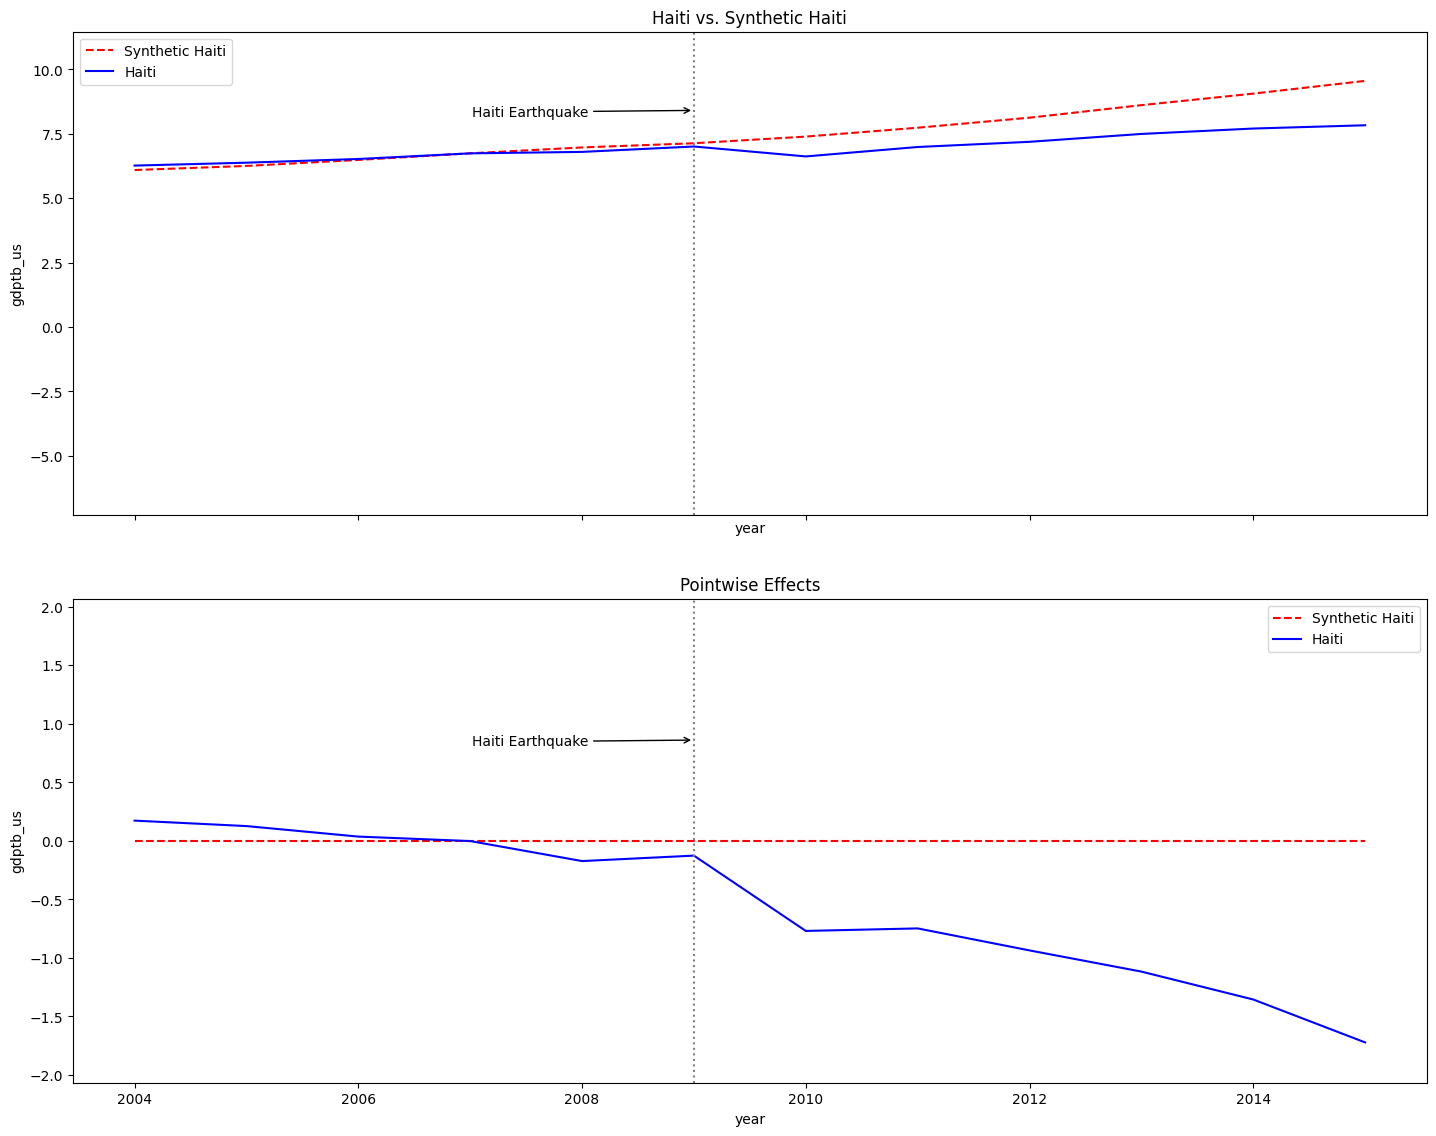

In [12]:
sc.plot(
    ["original", "pointwise"],
    treated_label="Haiti",
    synth_label="Synthetic Haiti",
    treatment_label="Haiti Earthquake",
)


Get weight matrix of solution


In [13]:
sc.original_data.weight_df


,Weight
Cameroon,0.273
Liberia,0.727


In [14]:
sc.original_data.comparison_df

,Haiti,Synthetic Haiti,WMAPE,Importance
gdptb_us,6.620,6.610,8.110,0.070
cons,100.200,184.950,93.920,0.200
exp,14.260,54.420,40.160,0.080
imp,42.950,158.680,126.790,0.090
gcf,28.490,19.320,9.170,0.060
land,27560.000,199124.530,171561.610,0.170
pop,9484519.000,7676933.420,6927419.640,0.060
inf,12.610,8.310,4.300,0.190
gdppc_w,1582.400,1159.210,954.100,0.080


**NOTE:** This algorithm results in a different weights for the Synthetic Haiti than Stata

Get synthetic outcomes for Haiti

In [15]:
haiti["Ysynthetic"] = sc.original_data.__dict__["synth_outcome"][0]
haiti["Ytreated"] = haiti["gdptb_us"]


Figure with total GDP in Haiti and synthethic control

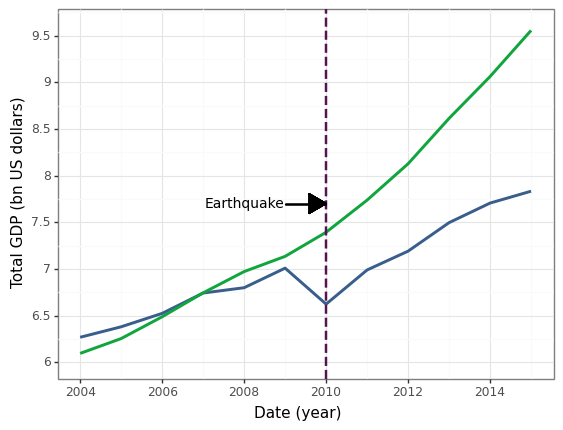

<ggplot: (396139418)>

In [16]:
(
    ggplot(haiti, aes(x="year", y="Ytreated"))
    + geom_line(color=color[0], size=1.2)
    + geom_line(aes(y="Ysynthetic"), color=color[1], size=1.2)
    + geom_vline(xintercept=2010, color=color[2], size=1, linetype="dashed")
    + labs(y="Total GDP (bn US dollars)", x="Date (year)")
    + geom_segment(
        aes(x=2009, y=7.7, xend=2010, yend=7.7), arrow=arrow(type="closed", ends="last")
    )
    + annotate("text", x=2008, y=7.7, label="Earthquake", size=10)
    + scale_y_continuous(breaks=seq(6, 9.6, 0.5), limits=(6, 9.6))
    + scale_x_continuous(breaks=seq(2004, 2015, 2), limits=(2004, 2015))
    + theme_bw()
)


 Figure with differenence in log total GDP

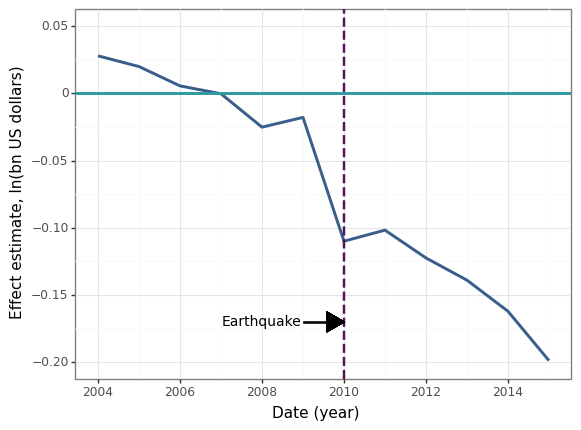

<ggplot: (396194774)>

In [17]:
(
    ggplot(haiti, aes(x="year", y="np.log(Ytreated) - np.log(Ysynthetic)"))
    + geom_line(color=color[0], size=1.2)
    + geom_vline(xintercept=2010, color=color[2], size=1, linetype="dashed")
    + geom_hline(yintercept=0, color=color[4], size=1.2)
    + labs(y="Effect estimate, ln(bn US dollars)", x="Date (year)")
    + geom_segment(
        aes(x=2009, y=-0.17, xend=2010, yend=-0.17),
        arrow=arrow(type="closed", ends="last"),
    )
    + annotate("text", x=2008, y=-0.17, label="Earthquake", size=10)
    + scale_y_continuous(breaks=seq(-0.2, 0.06, 0.05), limits=(-0.20, 0.05))
    + scale_x_continuous(breaks=seq(2004, 2015, 2), limits=(2004, 2015))
    + theme_bw()
)
